# Analisis visual de indices por pais: mejor lugar para vivir

Este notebook trabaja sobre el CSV principal generado por la pipeline reproducible de indices:
`projectData/processed/country_category_indices.csv`.

Objetivo:
- Validar la tabla final de paises e indices por categoria.
- Explorar cobertura, rankings, distribuciones y correlaciones.
- Reproducir un flujo similar al notebook de clustering: estandarizacion, PCA, metodo del codo, silhouette y K-Means.
- Interpretar grupos de paises segun las 9 categorias del indice.

Nota importante:
- `-1` significa sin datos suficientes o no concluyentes; no significa peor desempeno.


In [1]:
from __future__ import annotations

from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from kneed import KneeLocator

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

# El notebook puede ejecutarse desde la raiz del repo o desde la carpeta del notebook.
def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "projectData" / "processed" / "country_category_indices.csv").exists():
            return candidate
    raise FileNotFoundError("No se encontro projectData/processed/country_category_indices.csv")

PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "projectData" / "processed" / "country_category_indices.csv"
COVERAGE_PATH = PROJECT_ROOT / "projectData" / "processed" / "audit_category_coverage.csv"
VARIABLE_AUDIT_PATH = PROJECT_ROOT / "projectData" / "processed" / "audit_variable_scores.csv"

CATEGORY_COLUMNS = [
    "calidad_de_vida_y_bienestar",
    "economia_y_costo_de_vida",
    "salud_publica",
    "vivienda_y_urbanismo",
    "medioambiente_y_sostenibilidad",
    "seguridad_y_criminalidad",
    "gobernanza_y_libertades",
    "migracion_y_movilidad",
    "clima_y_desastres",
]

DATA_PATH


PosixPath('/Users/calata/Documents/Proyecto_BigData/projectData/processed/country_category_indices.csv')

## 1. Carga y validacion del documento principal

Cargamos el CSV final y sus archivos de auditoria. Luego validamos que todas las categorias esten en escala `0-100` o `-1`.


In [2]:
indices = pd.read_csv(DATA_PATH)
coverage = pd.read_csv(COVERAGE_PATH)
variable_audit = pd.read_csv(VARIABLE_AUDIT_PATH)

print(f"Paises/territorios en tabla final: {len(indices):,}")
print(f"Columnas: {len(indices.columns)}")
print(f"Filas de auditoria de cobertura: {len(coverage):,}")
print(f"Filas de auditoria por variable: {len(variable_audit):,}")
indices.head(10)


Paises/territorios en tabla final: 208
Columnas: 11
Filas de auditoria de cobertura: 1,872
Filas de auditoria por variable: 6,652


,country,country_iso3,calidad_de_vida_y_bienestar,economia_y_costo_de_vida,salud_publica,vivienda_y_urbanismo,medioambiente_y_sostenibilidad,seguridad_y_criminalidad,gobernanza_y_libertades,migracion_y_movilidad,clima_y_desastres
0,Afghanistan,AFG,11.06,37.08,25.74,100.00,71.07,16.16,25.24,5.80,39.68
1,Albania,ALB,53.20,33.81,81.12,50.16,75.05,59.80,60.60,43.57,67.58
2,Algeria,DZA,44.34,32.14,72.97,91.58,60.38,51.16,35.55,14.10,72.06
3,Andorra,AND,38.53,46.09,-1.00,62.88,78.29,-1.00,85.16,80.95,-1.00
4,Angola,AGO,-1.00,45.20,18.05,100.00,74.93,-1.00,33.15,10.87,48.79
5,Antigua and Barbuda,ATG,-1.00,42.98,81.42,65.98,-1.00,-1.00,85.00,67.38,27.35
6,Argentina,ARG,58.76,22.33,81.01,69.34,79.22,45.02,76.93,67.06,78.84
7,Armenia,ARM,55.53,30.04,78.43,64.22,77.07,77.45,60.69,19.33,79.29
8,Aruba,ABW,-1.00,-1.00,68.40,54.31,14.48,-1.00,-1.00,-1.00,-1.00
9,Australia,AUS,74.43,64.70,92.60,60.74,68.66,62.97,89.96,81.41,72.30


In [3]:
def validate_indices(df: pd.DataFrame) -> pd.DataFrame:
    checks = []
    checks.append({
        "check": "country_not_empty",
        "passed": bool(df["country"].notna().all() and df["country"].astype(str).str.strip().ne("").all()),
        "detail": int(df["country"].isna().sum()),
    })
    checks.append({
        "check": "iso3_not_empty",
        "passed": bool(df["country_iso3"].notna().all() and df["country_iso3"].astype(str).str.strip().ne("").all()),
        "detail": int(df["country_iso3"].isna().sum()),
    })
    for col in CATEGORY_COLUMNS:
        values = pd.to_numeric(df[col], errors="coerce")
        invalid = ~((values == -1) | ((values >= 0) & (values <= 100)))
        checks.append({
            "check": f"{col}_range",
            "passed": bool(values.notna().all() and not invalid.any()),
            "detail": int(invalid.sum()),
        })
    return pd.DataFrame(checks)

validation = validate_indices(indices)
display(validation)
assert validation["passed"].all(), "La tabla principal no cumple las reglas esperadas."


,check,passed,detail
0,country_not_empty,True,0
1,iso3_not_empty,True,0
2,calidad_de_vida_y_bienestar_range,True,0
3,economia_y_costo_de_vida_range,True,0
4,salud_publica_range,True,0
5,vivienda_y_urbanismo_range,True,0
6,medioambiente_y_sostenibilidad_range,True,0
7,seguridad_y_criminalidad_range,True,0
8,gobernanza_y_libertades_range,True,0
9,migracion_y_movilidad_range,True,0


## 2. Cobertura por categoria

Estos graficos explican una diferencia clave del proyecto: algunas categorias tienen datos para casi todos los paises, mientras que seguridad y calidad de vida dependen de fuentes con menor cobertura.


,categoria,paises_con_score,paises_con_menos_1,cobertura_pct,score_promedio,score_mediana
5,seguridad_y_criminalidad,113,95,54.33,59.17,59.86
0,calidad_de_vida_y_bienestar,148,60,71.15,52.37,53.66
3,vivienda_y_urbanismo,180,28,86.54,69.31,70.78
4,medioambiente_y_sostenibilidad,182,26,87.50,68.11,71.06
8,clima_y_desastres,184,24,88.46,65.82,69.42
1,economia_y_costo_de_vida,186,22,89.42,47.13,47.24
2,salud_publica,190,18,91.35,62.27,71.32
7,migracion_y_movilidad,198,10,95.19,40.49,35.40
6,gobernanza_y_libertades,203,5,97.60,58.10,59.12


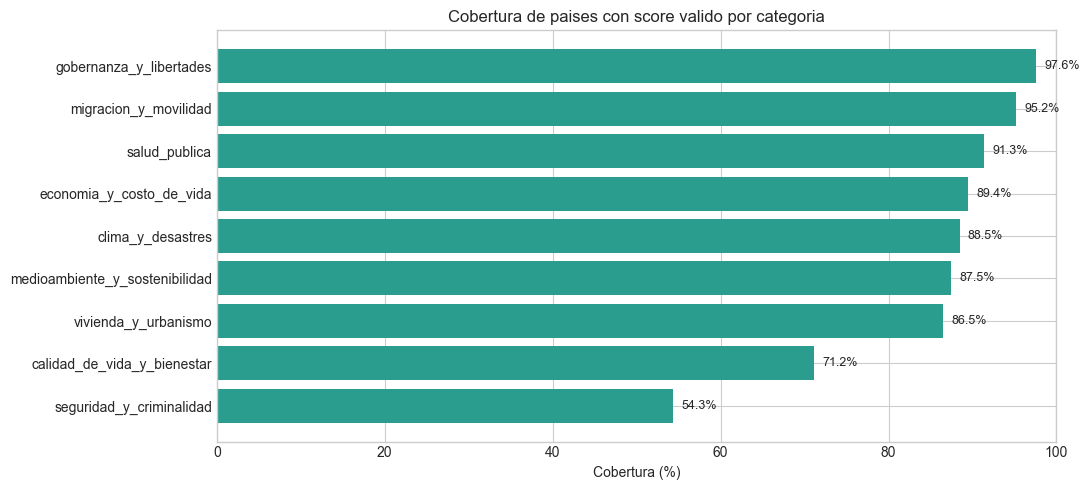

In [4]:
coverage_summary = []
for col in CATEGORY_COLUMNS:
    valid = indices[col] != -1
    coverage_summary.append({
        "categoria": col,
        "paises_con_score": int(valid.sum()),
        "paises_con_menos_1": int((~valid).sum()),
        "cobertura_pct": round(valid.mean() * 100, 2),
        "score_promedio": round(indices.loc[valid, col].mean(), 2) if valid.any() else np.nan,
        "score_mediana": round(indices.loc[valid, col].median(), 2) if valid.any() else np.nan,
    })
coverage_summary = pd.DataFrame(coverage_summary).sort_values("cobertura_pct")
display(coverage_summary)

fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(coverage_summary["categoria"], coverage_summary["cobertura_pct"], color="#2a9d8f")
ax.set_xlim(0, 100)
ax.set_xlabel("Cobertura (%)")
ax.set_title("Cobertura de paises con score valido por categoria")
for y, value in enumerate(coverage_summary["cobertura_pct"]):
    ax.text(value + 1, y, f"{value:.1f}%", va="center", fontsize=9)
plt.tight_layout()
plt.show()


## 3. Distribucion de scores por categoria

Cada histograma ignora los `-1`. Esto permite comparar la dispersion real de cada dimension.


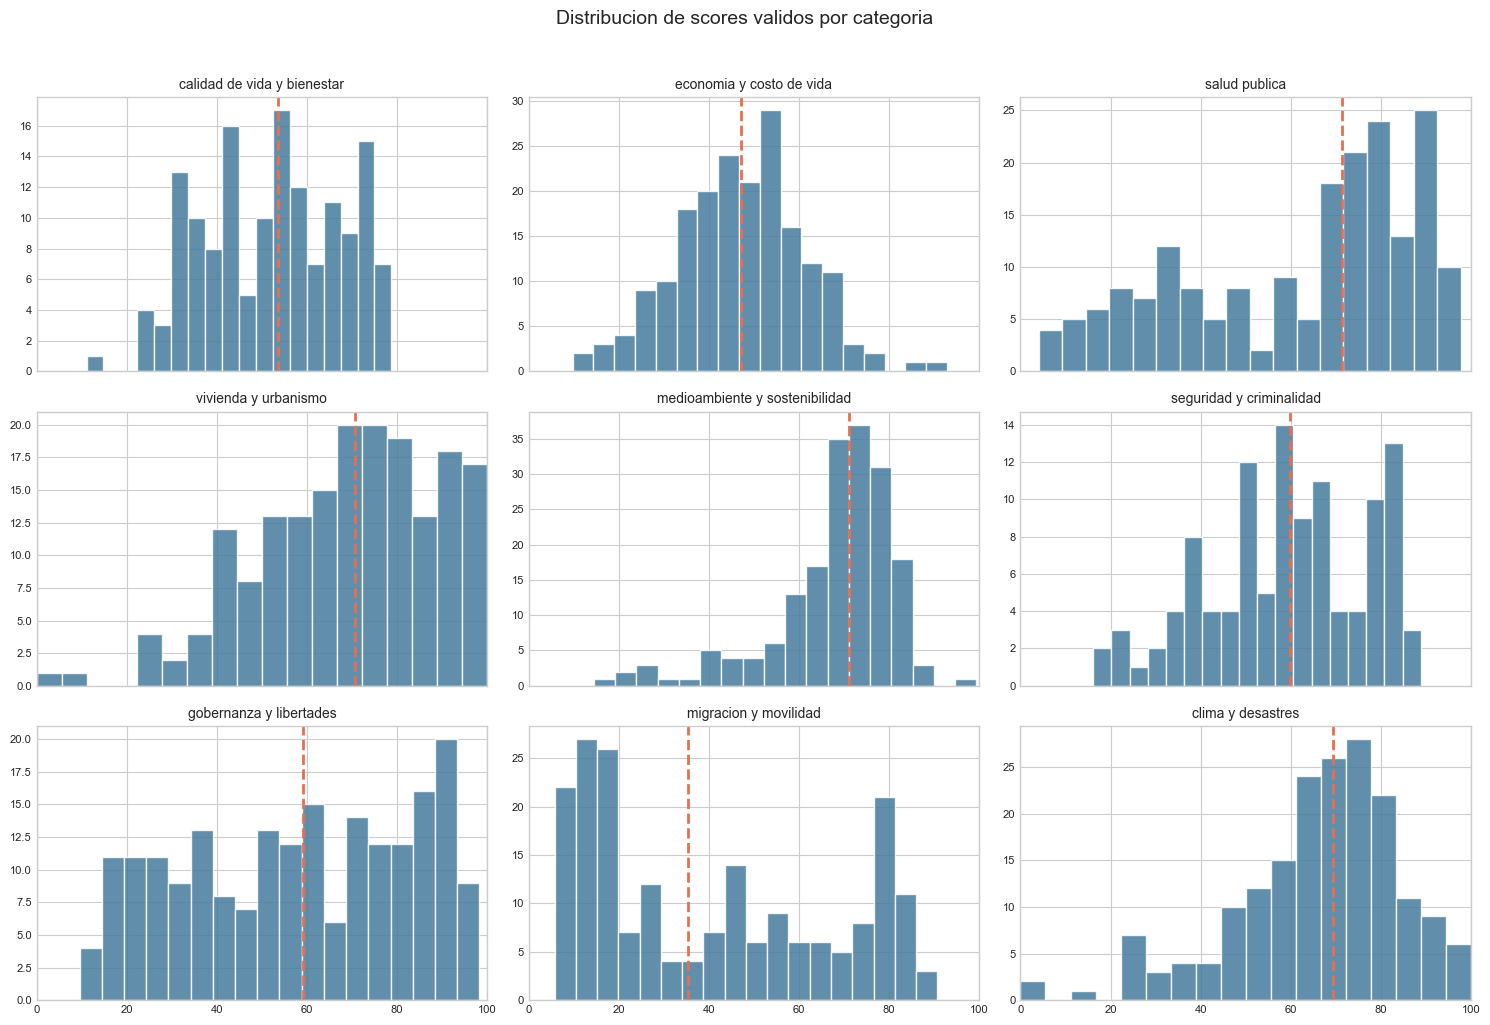

In [5]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10), sharex=True)
axes = axes.ravel()
for ax, col in zip(axes, CATEGORY_COLUMNS):
    values = indices.loc[indices[col] != -1, col]
    ax.hist(values, bins=18, color="#457b9d", alpha=0.85, edgecolor="white")
    ax.axvline(values.median(), color="#e76f51", linestyle="--", linewidth=2, label="mediana")
    ax.set_title(col.replace("_", " "), fontsize=10)
    ax.set_xlim(0, 100)
for ax in axes:
    ax.tick_params(labelsize=8)
plt.suptitle("Distribucion de scores validos por categoria", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## 4. Score global exploratorio

El score global no reemplaza las 9 categorias. Es una lectura rapida calculada como promedio de categorias disponibles.

Regla usada aqui:
- Convertimos `-1` a faltante.
- Calculamos `score_global` solo si el pais tiene al menos 5 categorias validas.
- Guardamos `categorias_validas` para no ocultar problemas de cobertura.


,country,country_iso3,score_global,categorias_validas,calidad_de_vida_y_bienestar,economia_y_costo_de_vida,salud_publica,vivienda_y_urbanismo,medioambiente_y_sostenibilidad,seguridad_y_criminalidad,gobernanza_y_libertades,migracion_y_movilidad,clima_y_desastres
160,San Marino,SMR,78.80,5,-1.00,61.75,91.20,77.12,-1.00,-1.00,95.00,68.93,-1.00
105,Luxembourg,LUX,78.61,9,74.09,69.46,93.90,46.89,65.91,79.35,92.89,90.06,94.97
180,Switzerland,CHE,78.41,9,74.77,73.15,93.60,50.90,75.32,83.91,92.94,84.95,76.13
84,Ireland,IRL,78.01,8,74.03,-1.00,88.57,65.94,73.11,73.29,94.92,82.19,72.03
79,Iceland,ISL,77.46,9,76.48,76.62,90.04,53.35,74.17,82.36,91.72,79.25,73.11
48,Denmark,DNK,77.26,9,78.64,69.31,88.83,43.38,79.37,83.07,95.12,80.54,77.11
129,Netherlands,NLD,76.83,9,77.12,65.76,90.34,62.10,73.17,82.90,95.05,80.87,64.19
165,Seychelles,SYC,76.79,7,-1.00,52.58,80.25,93.82,87.79,-1.00,71.73,61.70,89.63
137,Norway,NOR,76.77,9,75.91,70.48,92.49,47.07,75.93,78.10,98.31,81.19,71.41
103,Liechtenstein,LIE,76.71,5,-1.00,69.23,73.08,64.41,-1.00,-1.00,87.42,89.43,-1.00


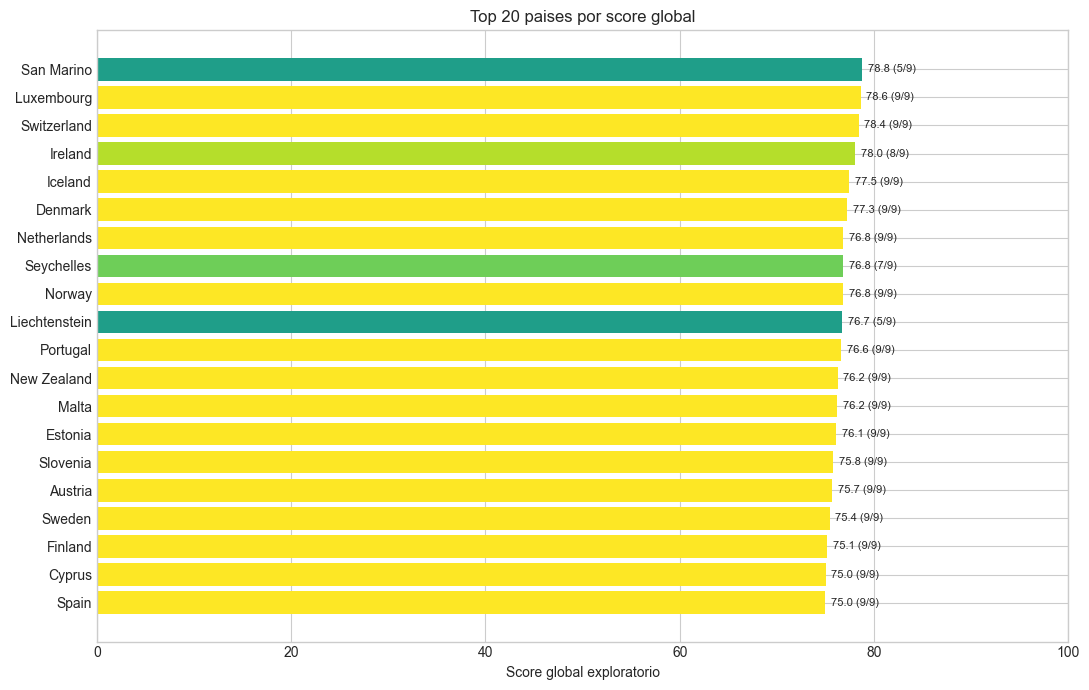

In [6]:
analysis = indices.copy()
score_matrix = analysis[CATEGORY_COLUMNS].replace(-1, np.nan)
analysis["categorias_validas"] = score_matrix.notna().sum(axis=1)
analysis["score_global"] = score_matrix.mean(axis=1)
analysis.loc[analysis["categorias_validas"] < 5, "score_global"] = np.nan
analysis["score_global"] = analysis["score_global"].round(2)

ranking = analysis.sort_values(["score_global", "categorias_validas"], ascending=[False, False])
ranking_cols = ["country", "country_iso3", "score_global", "categorias_validas", *CATEGORY_COLUMNS]
display(ranking[ranking_cols].head(20))

fig, ax = plt.subplots(figsize=(11, 7))
top20 = ranking.dropna(subset=["score_global"]).head(20).sort_values("score_global")
colors = plt.cm.viridis(top20["categorias_validas"] / 9)
ax.barh(top20["country"], top20["score_global"], color=colors)
ax.set_xlabel("Score global exploratorio")
ax.set_title("Top 20 paises por score global")
ax.set_xlim(0, 100)
for y, (score, valid) in enumerate(zip(top20["score_global"], top20["categorias_validas"])):
    ax.text(score + 0.6, y, f"{score:.1f} ({int(valid)}/9)", va="center", fontsize=8)
plt.tight_layout()
plt.show()


## 5. Comparacion de paises de interes

Ajusta `COUNTRIES_OF_INTEREST` para comparar cualquier grupo de paises. El heatmap permite ver rapidamente fortalezas y debilidades por categoria.


,country,country_iso3,score_global,categorias_validas,calidad_de_vida_y_bienestar,economia_y_costo_de_vida,salud_publica,vivienda_y_urbanismo,medioambiente_y_sostenibilidad,seguridad_y_criminalidad,gobernanza_y_libertades,migracion_y_movilidad,clima_y_desastres
175,Spain,ESP,74.98,9,71.66,41.83,91.07,70.92,79.32,74.48,85.47,81.33,78.70
67,Germany,DEU,74.79,9,73.83,61.66,94.61,59.83,72.29,67.97,91.18,82.26,69.49
32,Canada,CAN,72.71,9,74.82,65.75,88.64,66.39,65.14,66.11,92.65,78.12,56.74
89,Japan,JPN,71.40,9,68.37,61.74,97.75,55.02,71.06,82.69,83.42,74.11,48.46
198,United States,USA,69.10,9,69.77,52.62,85.81,66.55,60.05,50.25,81.27,75.21,80.37
25,Brazil,BRA,60.71,9,57.43,32.04,74.20,68.82,80.57,34.33,63.65,65.61,69.75
116,Mexico,MEX,60.03,9,60.54,44.10,71.36,73.40,66.95,43.33,52.26,59.81,68.54
80,India,IND,44.42,9,42.02,30.77,47.35,59.18,42.81,55.67,53.19,14.49,54.31


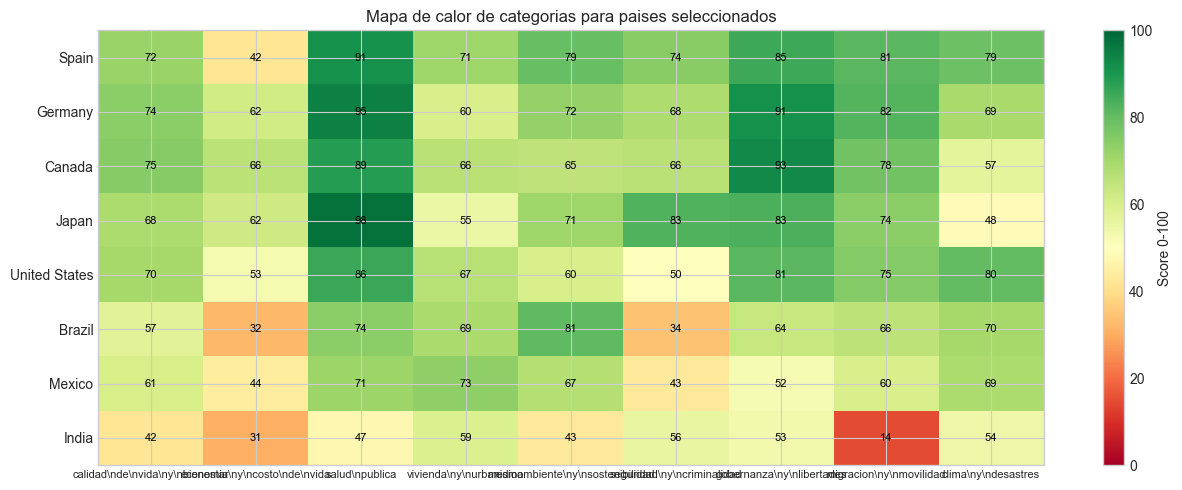

In [7]:
COUNTRIES_OF_INTEREST = [
    "Mexico",
    "United States",
    "Canada",
    "Spain",
    "Germany",
    "Japan",
    "Brazil",
    "India",
]

comparison = analysis[analysis["country"].isin(COUNTRIES_OF_INTEREST)].copy()
comparison = comparison.sort_values("score_global", ascending=False)
display(comparison[ranking_cols])

heatmap_data = comparison.set_index("country")[CATEGORY_COLUMNS].replace(-1, np.nan)
fig, ax = plt.subplots(figsize=(13, 5))
im = ax.imshow(heatmap_data, cmap="RdYlGn", vmin=0, vmax=100, aspect="auto")
ax.set_xticks(range(len(CATEGORY_COLUMNS)))
ax.set_xticklabels([c.replace("_", "\\n") for c in CATEGORY_COLUMNS], rotation=0, fontsize=8)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        value = heatmap_data.iloc[i, j]
        label = "-1" if pd.isna(value) else f"{value:.0f}"
        ax.text(j, i, label, ha="center", va="center", fontsize=8, color="black")
ax.set_title("Mapa de calor de categorias para paises seleccionados")
fig.colorbar(im, ax=ax, label="Score 0-100")
plt.tight_layout()
plt.show()


## 6. Perfil de fortalezas y debilidades

Funcion para explicar un pais de forma compacta con barras horizontales.


Mexico (MEX)
Score global: 60.03 | Categorias validas: 9/9

Debilidades:
seguridad_y_criminalidad    43.33
economia_y_costo_de_vida     44.1
gobernanza_y_libertades     52.26

Fortalezas:
vivienda_y_urbanismo     73.4
salud_publica           71.36
clima_y_desastres       68.54


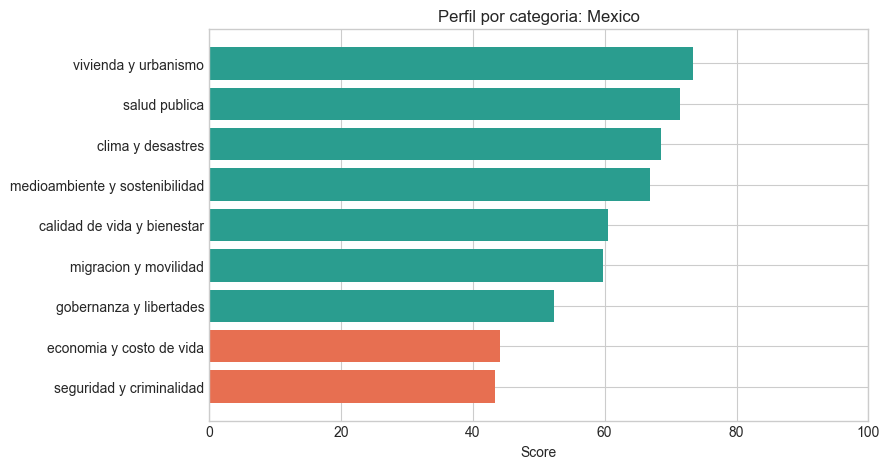

In [8]:
def country_profile(country: str, top_n: int = 3) -> pd.Series:
    row = analysis[analysis["country"].str.casefold() == country.casefold()]
    if row.empty:
        raise ValueError(f"No encontre el pais: {country}")
    row = row.iloc[0]
    scores = row[CATEGORY_COLUMNS].replace(-1, np.nan).dropna().sort_values()
    print(f"{row['country']} ({row['country_iso3']})")
    print(f"Score global: {row['score_global']} | Categorias validas: {int(row['categorias_validas'])}/9")
    print("\nDebilidades:")
    print(scores.head(top_n).to_string())
    print("\nFortalezas:")
    print(scores.tail(top_n).sort_values(ascending=False).to_string())

    fig, ax = plt.subplots(figsize=(9, 4.8))
    colors = ["#e76f51" if v < 50 else "#2a9d8f" for v in scores]
    ax.barh(scores.index.str.replace("_", " "), scores.values, color=colors)
    ax.set_xlim(0, 100)
    ax.set_xlabel("Score")
    ax.set_title(f"Perfil por categoria: {row['country']}")
    plt.tight_layout()
    plt.show()
    return scores

mexico_scores = country_profile("Mexico")


## 7. Correlaciones entre categorias

La matriz permite ver dimensiones que tienden a moverse juntas. Esta parte cumple una funcion similar a las visualizaciones exploratorias previas al clustering.


,calidad_de_vida_y_bienestar,economia_y_costo_de_vida,salud_publica,vivienda_y_urbanismo,medioambiente_y_sostenibilidad,seguridad_y_criminalidad,gobernanza_y_libertades,migracion_y_movilidad,clima_y_desastres
calidad_de_vida_y_bienestar,1.00,0.37,0.83,-0.57,-0.01,0.69,0.67,0.86,0.36
economia_y_costo_de_vida,0.37,1.00,0.20,-0.08,-0.11,0.45,0.21,0.37,-0.03
salud_publica,0.83,0.20,1.00,-0.48,-0.08,0.67,0.46,0.76,0.38
vivienda_y_urbanismo,-0.57,-0.08,-0.48,1.00,0.04,-0.55,-0.39,-0.51,-0.19
medioambiente_y_sostenibilidad,-0.01,-0.11,-0.08,0.04,1.00,-0.16,0.29,0.05,-0.07
seguridad_y_criminalidad,0.69,0.45,0.67,-0.55,-0.16,1.00,0.41,0.59,0.46
gobernanza_y_libertades,0.67,0.21,0.46,-0.39,0.29,0.41,1.00,0.72,0.11
migracion_y_movilidad,0.86,0.37,0.76,-0.51,0.05,0.59,0.72,1.00,0.25
clima_y_desastres,0.36,-0.03,0.38,-0.19,-0.07,0.46,0.11,0.25,1.00


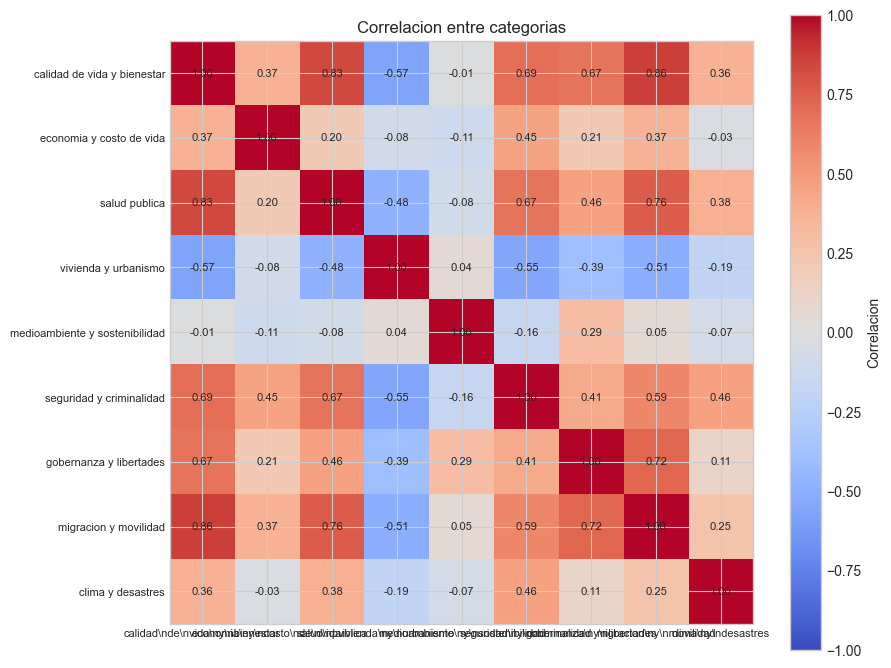

In [9]:
corr = score_matrix.corr().round(2)
display(corr)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(CATEGORY_COLUMNS)))
ax.set_xticklabels([c.replace("_", "\\n") for c in CATEGORY_COLUMNS], fontsize=8)
ax.set_yticks(range(len(CATEGORY_COLUMNS)))
ax.set_yticklabels([c.replace("_", " ") for c in CATEGORY_COLUMNS], fontsize=8)
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
ax.set_title("Correlacion entre categorias")
fig.colorbar(im, ax=ax, label="Correlacion")
plt.tight_layout()
plt.show()


## 8. Preparacion para clustering

Seguimos el mismo flujo conceptual que el notebook anterior:
1. Seleccionar variables numericas.
2. Imputar faltantes derivados de `-1`.
3. Estandarizar.
4. Reducir dimensionalidad con PCA.
5. Evaluar K-Means con codo y silhouette.


In [10]:
cluster_data = analysis[analysis["categorias_validas"] >= 7].copy()
cluster_matrix = cluster_data[CATEGORY_COLUMNS].replace(-1, np.nan)
cluster_matrix = cluster_matrix.fillna(cluster_matrix.median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_matrix)

pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

print(f"Paises usados para clustering: {len(cluster_data)}")
print("Varianza explicada por PCA:", np.round(pca.explained_variance_ratio_, 4))
print("Varianza acumulada:", round(float(pca.explained_variance_ratio_.sum()), 4))


Paises usados para clustering: 166
Varianza explicada por PCA: [0.4557 0.1418]
Varianza acumulada: 0.5975


## 9. PCA exploratorio

Antes de fijar clusters, visualizamos los paises en las dos primeras componentes principales.


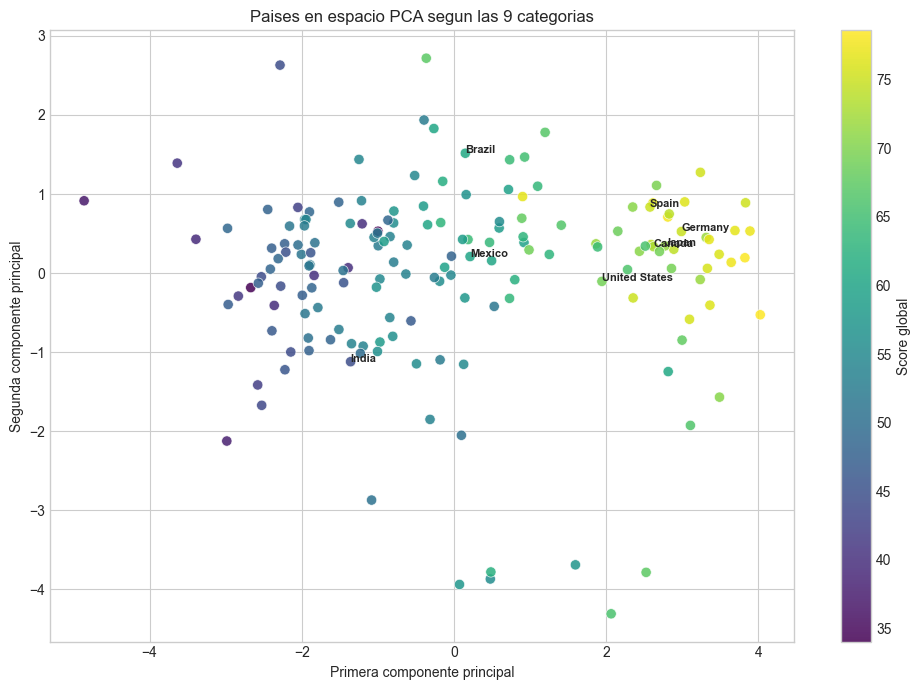

In [11]:
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cluster_data["score_global"],
    cmap="viridis",
    s=55,
    alpha=0.85,
    edgecolor="white",
    linewidth=0.5,
)
for country in COUNTRIES_OF_INTEREST:
    match = cluster_data.index[cluster_data["country"] == country]
    if len(match):
        pos = cluster_data.index.get_loc(match[0])
        ax.text(X_pca[pos, 0], X_pca[pos, 1], country, fontsize=8, weight="bold")
ax.set_xlabel("Primera componente principal")
ax.set_ylabel("Segunda componente principal")
ax.set_title("Paises en espacio PCA segun las 9 categorias")
fig.colorbar(scatter, ax=ax, label="Score global")
plt.tight_layout()
plt.show()


## 10. Eleccion de k: metodo del codo y silhouette

Replicamos las dos tecnicas del notebook de clustering original, ahora aplicadas al indice por pais.


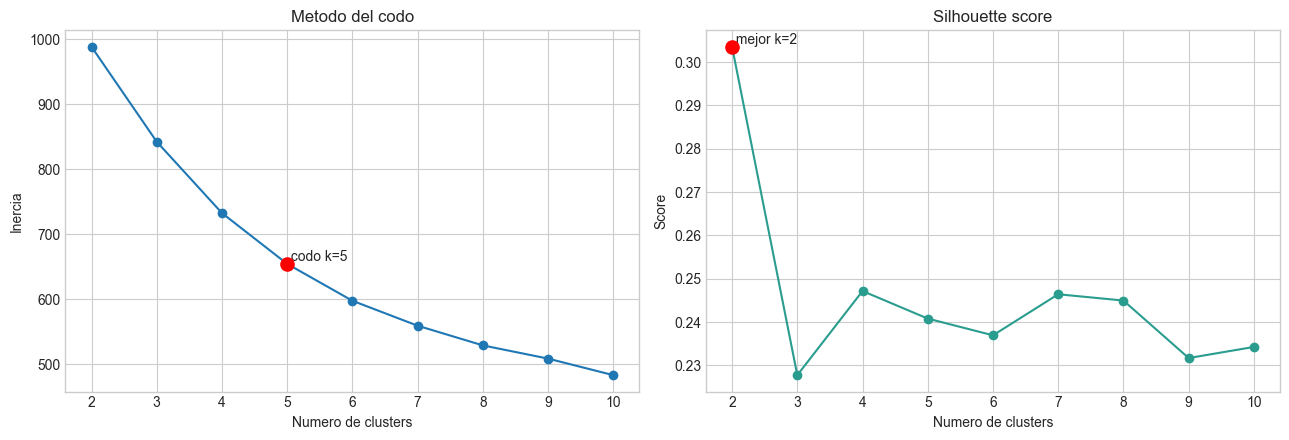

,k,inercia,silhouette
0,2,988.3969,0.3035
1,3,842.2063,0.2277
2,4,732.3852,0.2472
3,5,654.1368,0.2408
4,6,597.3765,0.2369
5,7,558.9623,0.2464
6,8,528.6902,0.2450
7,9,508.3247,0.2317
8,10,482.8646,0.2343


In [12]:
k_values = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=SEED, n_init=20)
    labels = model.fit_predict(X_scaled)
    inertias.append(model.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

kl = KneeLocator(list(k_values), inertias, curve="convex", direction="decreasing")
elbow_k = kl.elbow
best_silhouette_k = list(k_values)[int(np.argmax(silhouette_scores))]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(list(k_values), inertias, marker="o")
if elbow_k is not None:
    axes[0].scatter([elbow_k], [inertias[list(k_values).index(elbow_k)]], color="red", s=90, zorder=5)
    axes[0].text(elbow_k, inertias[list(k_values).index(elbow_k)], f" codo k={elbow_k}", va="bottom")
axes[0].set_title("Metodo del codo")
axes[0].set_xlabel("Numero de clusters")
axes[0].set_ylabel("Inercia")
axes[0].set_xticks(list(k_values))

axes[1].plot(list(k_values), silhouette_scores, marker="o", color="#2a9d8f")
axes[1].scatter([best_silhouette_k], [max(silhouette_scores)], color="red", s=90, zorder=5)
axes[1].text(best_silhouette_k, max(silhouette_scores), f" mejor k={best_silhouette_k}", va="bottom")
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("Numero de clusters")
axes[1].set_ylabel("Score")
axes[1].set_xticks(list(k_values))
plt.tight_layout()
plt.show()

pd.DataFrame({"k": list(k_values), "inercia": inertias, "silhouette": silhouette_scores}).round(4)


## 11. K-Means final e interpretacion visual

Usamos `k=4` como punto de partida interpretable. Puedes cambiar `K_FINAL` si el codo o silhouette sugieren otra decision.


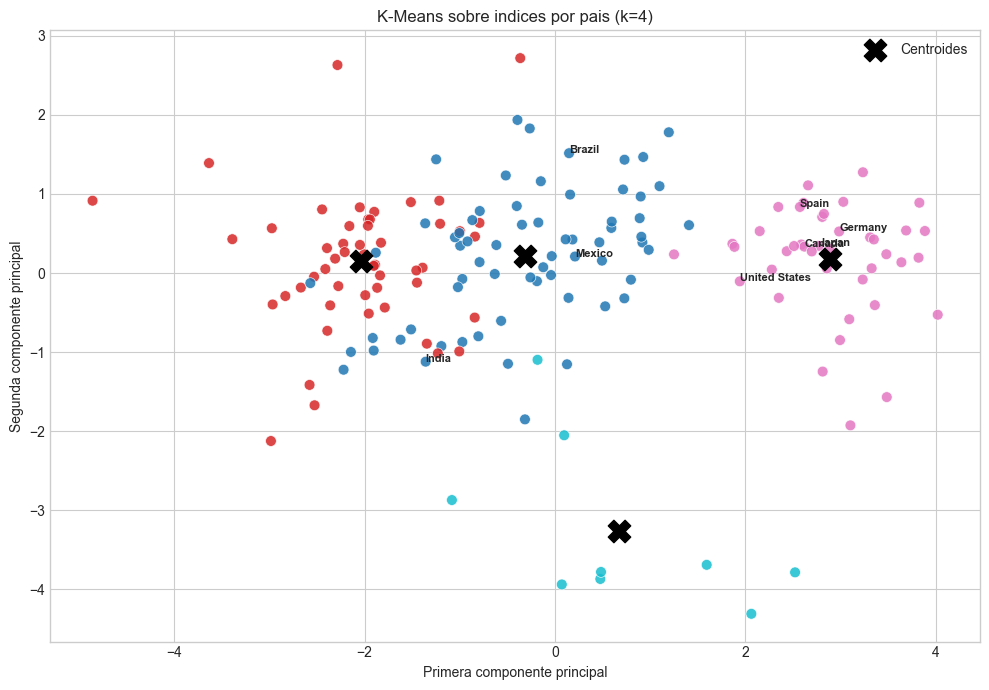

,paises,score_global_promedio,categorias_validas_promedio
cluster,,,
0,65,56.70,8.65
1,51,47.40,8.04
2,41,72.41,8.90
3,9,57.69,8.33


In [13]:
K_FINAL = 4
kmeans = KMeans(n_clusters=K_FINAL, random_state=SEED, n_init=20)
cluster_data["cluster"] = kmeans.fit_predict(X_scaled)
centroids_pca = PCA(n_components=2, random_state=SEED).fit(X_scaled).transform(kmeans.cluster_centers_)

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cluster_data["cluster"],
    cmap="tab10",
    s=60,
    alpha=0.85,
    edgecolor="white",
    linewidth=0.5,
)
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1], marker="X", s=260, c="black", label="Centroides")
for country in COUNTRIES_OF_INTEREST:
    match = cluster_data.index[cluster_data["country"] == country]
    if len(match):
        pos = cluster_data.index.get_loc(match[0])
        ax.text(X_pca[pos, 0], X_pca[pos, 1], country, fontsize=8, weight="bold")
ax.set_xlabel("Primera componente principal")
ax.set_ylabel("Segunda componente principal")
ax.set_title(f"K-Means sobre indices por pais (k={K_FINAL})")
ax.legend()
plt.tight_layout()
plt.show()

cluster_summary = cluster_data.groupby("cluster").agg(
    paises=("country", "count"),
    score_global_promedio=("score_global", "mean"),
    categorias_validas_promedio=("categorias_validas", "mean"),
).round(2)
display(cluster_summary)


## 12. Perfil promedio de clusters

Este heatmap ayuda a nombrar cada grupo. Por ejemplo: paises con alto bienestar y gobernanza, paises con buena vivienda pero baja movilidad, etc.


,calidad_de_vida_y_bienestar,economia_y_costo_de_vida,salud_publica,vivienda_y_urbanismo,medioambiente_y_sostenibilidad,seguridad_y_criminalidad,gobernanza_y_libertades,migracion_y_movilidad,clima_y_desastres
cluster,,,,,,,,,
0,50.98,38.60,71.64,70.33,70.40,50.00,51.97,34.98,67.93
1,35.46,47.65,29.61,84.03,70.72,43.00,41.90,14.95,55.44
2,70.79,56.59,89.46,51.00,70.96,73.74,84.35,77.86,76.31
3,60.03,67.60,79.62,69.95,31.44,76.50,26.56,46.37,70.63


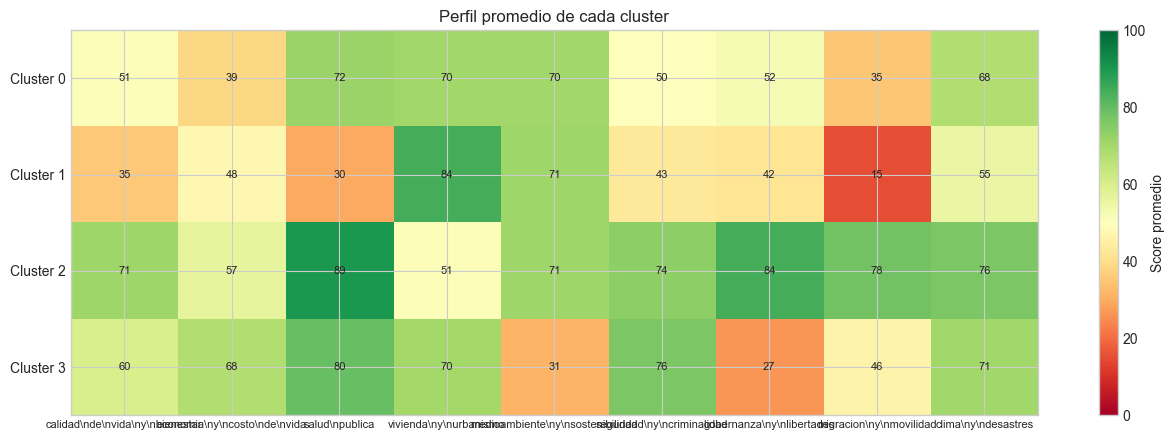

Ejemplos de paises por cluster:

Cluster 0
    country  score_global  categorias_validas
 Seychelles         76.79                   7
Saint Lucia         68.96                   7
  Mauritius         67.84                   8
    Uruguay         66.89                   9
     Greece         66.54                   9
 Costa Rica         65.04                   9
  Argentina         64.28                   9
   Maldives         64.20                   8
   Paraguay         63.76                   9
      Chile         63.50                   9

Cluster 1
          country  score_global  categorias_validas
  Solomon Islands         67.16                   7
            Nepal         56.24                   9
          Bolivia         55.68                   9
       Madagascar         54.31                   8
           Rwanda         54.11                   7
           Malawi         53.98                   8
           Gambia         53.97                   7
        Indonesia       

In [14]:
cluster_profiles = cluster_data[["cluster", *CATEGORY_COLUMNS]].replace(-1, np.nan).groupby("cluster").mean().round(2)
display(cluster_profiles)

fig, ax = plt.subplots(figsize=(13, 4.5))
im = ax.imshow(cluster_profiles, cmap="RdYlGn", vmin=0, vmax=100, aspect="auto")
ax.set_xticks(range(len(CATEGORY_COLUMNS)))
ax.set_xticklabels([c.replace("_", "\\n") for c in CATEGORY_COLUMNS], fontsize=8)
ax.set_yticks(range(len(cluster_profiles.index)))
ax.set_yticklabels([f"Cluster {i}" for i in cluster_profiles.index])
for i in range(cluster_profiles.shape[0]):
    for j in range(cluster_profiles.shape[1]):
        ax.text(j, i, f"{cluster_profiles.iloc[i, j]:.0f}", ha="center", va="center", fontsize=8)
ax.set_title("Perfil promedio de cada cluster")
fig.colorbar(im, ax=ax, label="Score promedio")
plt.tight_layout()
plt.show()

print("Ejemplos de paises por cluster:")
for cluster_id, group in cluster_data.sort_values("score_global", ascending=False).groupby("cluster"):
    examples = group[["country", "score_global", "categorias_validas"]].head(10)
    print(f"\nCluster {cluster_id}")
    print(examples.to_string(index=False))


## 13. Auditoria de fuentes y pesos

Esta seccion permite revisar la trazabilidad del indice: que variables entraron, de que fuente vienen y que peso aportan.


,category,variable,source,weight,primary
1,calidad_de_vida_y_bienestar,world_happiness_ladder_score_2024,world-happiness-2024/World-happiness-report-20...,0.45,True
6,calidad_de_vida_y_bienestar,city_quality_of_life_composite,city-quality-of-life-dataset/uaScoresDataFrame...,0.30,True
0,calidad_de_vida_y_bienestar,global_prosperity_average_rank_inverted,2023-global-prosperity-index-w-region-politics...,0.25,False
401,clima_y_desastres,world_risk_index_inverted,global-disaster-risk-index/world_risk_index.csv,0.45,True
403,clima_y_desastres,temperature_comfort_score,daily-temperature-major-cities/city_temperatur...,0.35,True
400,clima_y_desastres,historical_disaster_frequency_impact_inverted,all-natural-disasters-19002021-eosdis/DISASTER...,0.20,False
911,economia_y_costo_de_vida,gdp_per_capita,countries-of-the-world-2023/world-data-2023.csv,0.25,False
914,economia_y_costo_de_vida,unemployment_rate_inverted,countries-of-the-world-2023/world-data-2023.csv,0.20,False
909,economia_y_costo_de_vida,cost_of_living_affordability_salary_vs_basics,global-cost-of-living/cost-of-living_v2.csv,0.15,True
910,economia_y_costo_de_vida,cpi_change_inverted,countries-of-the-world-2023/world-data-2023.csv,0.15,False


reason,insufficient_coverage,no_data,ok
category,,,
calidad_de_vida_y_bienestar,19,41,148
clima_y_desastres,7,17,184
economia_y_costo_de_vida,10,12,186
gobernanza_y_libertades,0,5,203
medioambiente_y_sostenibilidad,16,10,182
migracion_y_movilidad,4,6,198
salud_publica,1,17,190
seguridad_y_criminalidad,51,44,113
vivienda_y_urbanismo,0,28,180


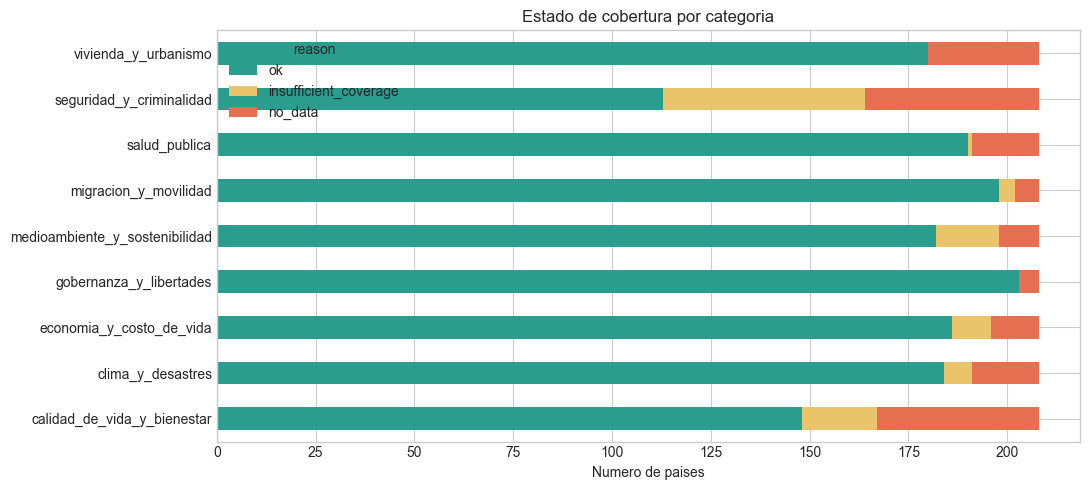

In [15]:
variables_by_category = (
    variable_audit[["category", "variable", "source", "weight", "primary"]]
    .drop_duplicates()
    .sort_values(["category", "weight", "variable"], ascending=[True, False, True])
)
display(variables_by_category)

coverage_reasons = coverage.groupby(["category", "reason"]).size().unstack(fill_value=0)
display(coverage_reasons)

fig, ax = plt.subplots(figsize=(11, 5))
coverage_reasons[[c for c in ["ok", "insufficient_coverage", "no_data"] if c in coverage_reasons.columns]].plot(
    kind="barh",
    stacked=True,
    ax=ax,
    color=["#2a9d8f", "#e9c46a", "#e76f51"][: len(coverage_reasons.columns)],
)
ax.set_title("Estado de cobertura por categoria")
ax.set_xlabel("Numero de paises")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


## 14. Siguientes pasos

- Revisar `projectData/processed/unmatched_country_names.csv` para aumentar cobertura y limpiar alias adicionales.
- Probar perfiles ponderados por usuario: estudiante, familia, nomada digital, retiro, inversionista.
- Comparar clusters usando `k=3`, `k=5` y `k=6` para evaluar interpretabilidad.
- Exportar rankings por perfil una vez que el criterio de pesos este cerrado.
